# Agent Evaluation Mini-Case: Why Final-Answer Metrics Miss the Story

**O'Reilly Live Course**: *Statistical Testing for LLM Evaluations*
**Subtitle**: *Design Experiments to Measure Gen AI Features at Scale*
**Instructor**: Rudrendu Paul
**Section 4 (10 min). Production Failure Case 2 of 2: The benchmark-production gap (5 min)**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rudrendupaul/llm-evals-course/blob/main/notebooks/04-agent-evaluation-mini-case.ipynb)

---

## What this notebook covers

Evaluating a single LLM call is hard. Evaluating an **AI agent** is harder. The agent's behavior emerges from a sequence of decisions: tool selection, planning, memory management, error recovery. The final answer captures almost none of that.

Here is the setup from Section 4 of the live course. Two agents get evaluated on roughly 200 tasks. Agent A wins on final-answer accuracy through brute force, with more retries and more tool calls. Then you turn on production constraints (latency, rate limits, timeouts) and Agent A's success rate drops sharply, while the leaner Agent B barely moves. Final-answer evaluation never sees this coming. Trajectory-level and efficiency metrics do.

A correct final answer can come from a broken process. An incorrect answer can come from a sound process that hit a bad input. Look only at final answers and you cannot tell the two apart.

The notebook walks through four sections:

1. **Simulate** agent task execution with realistic multi-level metrics
2. **Expose** the final-answer trap: why optimizing on answer quality alone misleads you
3. **Apply** multi-level evaluation across trajectory, efficiency, and outcome
4. **Compare** Agent A vs. Agent B under production constraints

Companion book: *Statistical Evaluation Methods for AI Systems* (Paul, O'Reilly, forthcoming). Chapter 11 covers this in full.

---

## Setup

Install dependencies. In Colab these come preinstalled; the `pip install` is a safety net for local environments.

> **INSTRUCTOR NOTE**: This cell is intentionally silent (the `-q` flag suppresses output). If a student sees red text here, it is a version conflict, not a fatal error. The libraries used (`scipy`, `statsmodels`, `matplotlib`, `numpy`, `pandas`, `seaborn`) are the standard data science stack. No agent framework or LLM API is required. We work with simulated data to keep the focus on the *evaluation logic*, not the infrastructure.

In [1]:
!pip install -q scipy statsmodels matplotlib numpy pandas seaborn

zsh:1: command not found: pip


---

## Imports and plot configuration

We set a global random seed here. That keeps things reproducible: run the notebook top to bottom and you get the same simulated data, the same statistical results, and the same charts every time. Students can change `np.random.seed(42)` to any other integer and watch the numbers shift. The values move, but the direction of the conclusions should hold.

> **INSTRUCTOR NOTE**: The two color constants `AGENT_A_COLOR` and `AGENT_B_COLOR` are defined once here and reused in every chart. That is good practice for reproducible teaching materials. If you want to switch Agent A to red and Agent B to green for color-blind accessibility, you change two lines, not twenty. Point this out as a software engineering habit that carries over directly to production eval dashboards.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

# Fix the random seed BEFORE any data generation.
# WHY: Reproducibility is a first-class requirement in eval pipelines.
# A seed-less notebook produces different numbers on every run, making it
# impossible to compare results across team members or across time.
np.random.seed(42)

# ── Plot aesthetics ──────────────────────────────────────────────────────────
# WHY whitegrid: grid lines help readers read off values from bar and line charts
# without needing to trace to the y-axis. The alternative (darkgrid) adds visual
# noise that competes with the data ink.
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,          # high-DPI for projectors and retina screens
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.spines.top': False,   # remove chart junk: top and right spines add nothing
    'axes.spines.right': False,
})

# Define agent colors once. Use throughout every chart for visual consistency.
# WHY a warm orange for Agent A and a cool blue for Agent B:
# Warm/cool contrast is intuitive: "hot" Agent A is aggressive/expensive,
# "cool" Agent B is measured/efficient. Avoid red/green (colorblind accessibility).
AGENT_A_COLOR = '#E07B54'   # warm orange, Agent A (brute-force, answer-optimized)
AGENT_B_COLOR = '#4A90D9'   # cool blue, Agent B (efficient, trajectory-optimized)

print('All imports successful.')

All imports successful.


---

## Section 1: Simulating agent task execution

### WHY THIS MATTERS

We simulate two AI agents to reproduce a pattern that shows up again and again in production. Agent A hits high final-answer accuracy through brute force: more steps, more retries, sloppy tool use. Agent B lands slightly lower accuracy but gets there through a cleaner, more efficient process.

In production, Agent A's approach is fragile. It only works when there is enough time, compute, and API headroom to keep retrying. Agent B's approach holds up even when those run short. That difference is invisible if you only measure final answers.

**Production scenario**: A financial services firm builds two versions of a research agent. Agent A, built by the team with the most ML experience, scores 92% on internal benchmarks. It tries multiple tools per query, retries on uncertainty, and almost always lands on a correct answer given enough time. Agent B, built by a smaller team, scores 88% on the same benchmark. The firm ships Agent A. Six months later their LLM provider raises API prices by 40% and adds rate limits during peak hours. Agent A's cost triples. Its success rate under load drops to 71%. The team goes back to Agent B and finds it still runs at 85% success while costing half as much. This notebook shows you the eval framework that would have caught this before shipment.

---

### The five metrics we track, and why each one matters

| Metric | Type | What it captures |
|---|---|---|
| `task_success` | Binary 0/1 | Did the agent complete the goal? |
| `num_steps` | Integer 1–8 | How many action steps the agent took |
| `tool_selection_accuracy` | 0–1 | Fraction of steps where the agent picked the right tool |
| `trajectory_efficiency` | 0–1 | Ratio of optimal steps to steps taken |
| `final_answer_quality` | 0–1 | Quality score for the final output |

- **`task_success`**: Binary and necessary, but not sufficient: an agent that flails through 12 tool calls before succeeding scores the same 1 as one that solves the task in 3 targeted steps.
- **`num_steps`**: More steps mean more API calls, more cost, more latency, and more chances to fail, so an agent that solves a 3-step problem in 7 steps is working badly, not failing outright.
- **`tool_selection_accuracy`**: Captures decision quality at each choice point, not just whether the final output was right. A web-search agent that reaches for the calculator first wastes a step.
- **`trajectory_efficiency`**: The metric most correlated with production resilience under latency and timeout constraints. An efficiency of 0.7 means the agent took 43% more steps than necessary.
- **`final_answer_quality`**: The most natural metric to read, and the one most likely to mislead when read in isolation, because it says nothing about the path that produced it.

---

**Agent A** is tuned for final answer quality. It over-explores, picks suboptimal tools often, but usually brute-forces its way to an acceptable answer.
**Agent B** is tuned for trajectory efficiency. It makes precise tool choices, takes fewer steps, and its final answers come out slightly weaker, but its process is far more reliable.

> **INSTRUCTOR NOTE**: The parameter choices in the simulation code are deliberate and worth saying out loud:
> - Agent A's `tool_selection_accuracy` mean is 0.63, so roughly 1 in 3 tool choices is wrong. Ask students what that looks like in a live trace. The agent calls `web_search` when it should have called `calculator`, gets irrelevant results, then tries again. Each wrong tool choice is one wasted step, one extra API call, one extra slice of latency.
> - Agent B's `trajectory_efficiency` mean is 0.79. On average that means about 27% more steps than the theoretical optimum (1 / 0.79 ≈ 1.27). Still imperfect, since a truly optimal agent would sit near 1.0, but much better than Agent A's 0.52.
> - We use `np.clip` on the continuous metrics to keep values in [0, 1]. In a production eval pipeline you would enforce those bounds at the schema layer (Pydantic validators, say), not after the fact.
>
> **Discussion question to pose here**: *"Why do you think Agent B has slightly lower `final_answer_quality` than Agent A? If it makes better tool choices and takes fewer steps, shouldn't its answers be better too?"* Let students debate. The answer: Agent A's extra steps often pull in more context or try several answer strategies. That over-retrieval sometimes improves the final answer even while it inflates cost and latency. That is the trade-off at the heart of this whole case.

In [3]:
# ── RATIONALE ───────────────────────────────────────────────────────────────
# We simulate 200 tasks per agent. Why 200?
# - Large enough that sampling noise does not dominate the results
#   (central limit theorem kicks in reliably around N=30, but 200 gives tight CIs)
# - Small enough that the bootstrap loop in Section 3 runs in seconds
# - Production evals often have 100–500 labeled tasks; 200 is realistic
# ─────────────────────────────────────────────────────────────────────────────
N = 200  # tasks per agent

# ── Agent A: high final-answer quality, poor trajectory efficiency ────────────
# Design intent: Agent A is what you get when you optimize purely for correctness
# during development. It uses a "try everything" strategy: broad tool calls,
# multiple retrieval attempts, extensive context gathering. It works. It just
# works expensively and fragily.
agent_a = pd.DataFrame({
    'agent': 'Agent A',
    'task_id': np.arange(N),

    # task_success ~ Binomial(p=0.84): Agent A completes ~84% of tasks.
    # WHY binomial: task completion is binary (did it succeed or not?).
    # p=0.84 means roughly 1 in 6 tasks fails even in benchmark conditions.
    'task_success': np.random.binomial(1, 0.84, N),

    # num_steps ~ Uniform(4, 8): Agent A takes 4–8 steps per task.
    # WHY 4–8: A simple 3-tool task should take 3 steps; Agent A adds 1–5 extra
    # steps through redundant retries and exploratory tool calls.
    'num_steps': np.random.randint(4, 9, N),          # 4–8 steps: over-explorer

    # tool_selection_accuracy ~ Normal(0.63, 0.12), clipped to [0.2, 0.95].
    # WHY 0.63: Agent A picks the wrong tool ~37% of the time at each step.
    # This is not random guessing (50%): Agent A has some planning ability,
    # but it is far from precise. In practice this means 1 in 3 tool calls is
    # a wasted API call.
    'tool_selection_accuracy': np.clip(
        np.random.normal(0.63, 0.12, N), 0.2, 0.95),

    # trajectory_efficiency ~ Normal(0.52, 0.11), clipped to [0.2, 0.85].
    # WHY 0.52: efficiency of 0.52 means Agent A takes almost twice as many steps
    # as the optimum on average (1/0.52 ≈ 1.92x the minimum required steps).
    # This is the "brute force" signature.
    'trajectory_efficiency': np.clip(
        np.random.normal(0.52, 0.11, N), 0.2, 0.85),

    # final_answer_quality ~ Normal(0.81, 0.09), clipped to [0.4, 0.99].
    # WHY 0.81: despite the inefficient process, Agent A's final answers are
    # good. The extra tool calls and context gathering do improve output quality,
    # which is why final-answer-only metrics make it look like the winner.
    'final_answer_quality': np.clip(
        np.random.normal(0.81, 0.09, N), 0.4, 0.99),
})

# ── Agent B: slightly lower final-answer, much better trajectories ────────────
# Design intent: Agent B is what you get when you optimize for process quality.
# It uses a "plan first, act precisely" strategy: fewer tool calls, targeted
# retrieval, minimal retries. Its final answers are slightly weaker because
# it commits to fewer retrieval attempts and stops when it has enough information.
agent_b = pd.DataFrame({
    'agent': 'Agent B',
    'task_id': np.arange(N),

    # task_success ~ Binomial(p=0.81): Agent B completes ~81% of tasks.
    # WHY 0.81 vs Agent A's 0.84: a 3-point gap in benchmark success rates.
    # This is the number that would make a naive team choose Agent A.
    'task_success': np.random.binomial(1, 0.81, N),

    # num_steps ~ Uniform(2, 5): Agent B takes 2–5 steps per task.
    # WHY 2–5: efficient agents can often complete a simple task in 2–3 steps.
    # Even for complex tasks, Agent B rarely needs more than 5.
    'num_steps': np.random.randint(2, 6, N),           # 2–5 steps: efficient

    # tool_selection_accuracy ~ Normal(0.84, 0.08), clipped to [0.55, 0.99].
    # WHY 0.84: Agent B picks the right tool ~84% of the time. This is not
    # perfect, but it means only 1 in 6 tool choices is wrong, compared to
    # Agent A's 1 in 3.
    'tool_selection_accuracy': np.clip(
        np.random.normal(0.84, 0.08, N), 0.55, 0.99),

    # trajectory_efficiency ~ Normal(0.79, 0.09), clipped to [0.5, 0.99].
    # WHY 0.79: Agent B takes about 27% more steps than the theoretical optimum
    # (1/0.79 ≈ 1.27x). Much better than Agent A's 1.92x, but still imperfect.
    'trajectory_efficiency': np.clip(
        np.random.normal(0.79, 0.09, N), 0.5, 0.99),

    # final_answer_quality ~ Normal(0.75, 0.10), clipped to [0.4, 0.99].
    # WHY 0.75 vs Agent A's 0.81: a 6-point gap in final answer quality.
    # This is the metric that makes Agent A look better on benchmarks.
    # The key question this notebook answers: is 6 points of answer quality
    # worth the process fragility? (Spoiler: for most production systems, no.)
    'final_answer_quality': np.clip(
        np.random.normal(0.75, 0.10, N), 0.4, 0.99),
})

# Combine into a single DataFrame for analysis
df = pd.concat([agent_a, agent_b], ignore_index=True)

# ── Print summary statistics ──────────────────────────────────────────────────
# WHY this summary table: always look at the raw numbers before plotting.
# Plots compress information; the table shows the values we will reference
# throughout the rest of the notebook.
summary = df.groupby('agent').agg(
    task_success_rate=('task_success', 'mean'),
    avg_steps=('num_steps', 'mean'),
    tool_selection_accuracy=('tool_selection_accuracy', 'mean'),
    trajectory_efficiency=('trajectory_efficiency', 'mean'),
    final_answer_quality=('final_answer_quality', 'mean'),
).round(3)

print('Simulated data summary:')
print(summary.to_string())

# ── What to look for in this output ──────────────────────────────────────────
# Agent A wins on: final_answer_quality (by ~0.06)
# Agent B wins on: tool_selection_accuracy (~0.21 higher), trajectory_efficiency (~0.27 higher)
# Both are close on: task_success_rate (~0.03 gap)
# Agent A avg_steps is ~1.5–2x Agent B avg_steps
#
# If your team only looks at task_success_rate and final_answer_quality,
# you will ship Agent A. The next two sections show why that is a mistake.

Simulated data summary:
         task_success_rate  avg_steps  tool_selection_accuracy  trajectory_efficiency  final_answer_quality
agent                                                                                                      
Agent A              0.845      6.035                    0.633                  0.515                 0.816
Agent B              0.815      3.505                    0.845                  0.800                 0.755


---

## Section 2: The final-answer trap

### WHY THIS MATTERS

This is the agent version of the end-to-end metric trap from the RAG notebook. Measure only final answers and Agent A wins. But Agent A is a brute-force solver. It tries more tools, takes more steps, and leans on retries to eventually land the right answer. It looks great on benchmarks because benchmarks hand out unlimited time and compute. Production does not.

The failure mode is specific and predictable. A team runs the evaluation, sees Agent A beat Agent B on final answer quality, ships Agent A, and three months later watches production success collapse when API latency spikes, rate limits kick in, or context windows fill up. The agent was never tested under the conditions it would face in the field.

Most agent eval pipelines do just what this section demonstrates: score the final output and call it done. If your evaluator never looks at the trajectory, you cannot catch:

- An agent that always fires 3 redundant tools before landing on the right answer
- An agent that breezes through easy tasks but breaks without warning on tasks that need precise tool sequencing
- An agent whose answer quality degrades gracefully while its token spend explodes

We run a two-proportion z-test on `final_answer_quality` (binarized at the median threshold) to show that Agent A "wins" the standard eval. Then we show why that conclusion is wrong.

> **INSTRUCTOR NOTE**: The binarization step is worth pausing on. We convert `final_answer_quality`, a continuous 0–1 score, into a binary "high quality / low quality" label at the median. That is how most production eval pipelines work: set a quality threshold, report pass/fail rates.
>
> The z-test is the right statistical test for comparing two proportions from two independent samples. Point out its three components:
> 1. **H0**: Agent A's high-quality rate = Agent B's high-quality rate (no difference)
> 2. **H1**: Agent A's rate > Agent B's rate (one-sided, because we are testing the team's specific hypothesis that A is better)
> 3. **p < 0.05**: reject the null, conclude Agent A is significantly better
>
> Emphasize this: the z-test is correct given the data it sees. The problem is not the statistics, it is the metric. Statistical rigor applied to the wrong metric is still wrong.
>
> **Common student confusion**: "If the test is significant, isn't Agent A better?" The answer: better on *this metric*, in *this test condition*. Whether that carries over to production is a separate question, and we answer it in Sections 3 and 4.

---

### KEY INSIGHT: What "winning" on final answer quality means

The z-test says Agent A has a statistically significantly higher rate of high-quality answers. A team that stops here ships Agent A. Three months later, when API latency spikes during peak hours, Agent A's success rate collapses because its retry-heavy strategy cannot finish inside the timeout. The final-answer metric held up: Agent A does produce better answers under ideal conditions. The trouble is that ideal conditions are not production conditions.

In [4]:
# ── RATIONALE ───────────────────────────────────────────────────────────────
# This cell replicates the most common agent evaluation mistake: binarize the
# final answer quality score at a threshold, then run a statistical test.
# The test is methodologically sound. The mistake is treating its result as
# the full picture.
# ─────────────────────────────────────────────────────────────────────────────

# Binarize final_answer_quality at the overall median.
# WHY the overall median (not a fixed threshold like 0.75)?
# Using the population median makes this a fair comparison: we classify the
# top 50% of *all* answers as "high quality", regardless of which agent produced
# them. A fixed threshold would embed a judgment about what "good" means;
# the median lets the data define the threshold. In practice, teams should
# calibrate their threshold to business requirements (e.g., "any score below
# 0.7 is unacceptable for a customer-facing response").
quality_threshold = df['final_answer_quality'].median()

# Create binary "high quality" indicator for each agent's tasks
# 1 = answer is at or above the quality threshold; 0 = below threshold
df['high_quality_answer'] = (df['final_answer_quality'] >= quality_threshold).astype(int)

a_hq = agent_a['final_answer_quality'].apply(lambda x: 1 if x >= quality_threshold else 0)
b_hq = agent_b['final_answer_quality'].apply(lambda x: 1 if x >= quality_threshold else 0)

# Count how many tasks each agent produced "high quality" answers for
count_hq = np.array([a_hq.sum(), b_hq.sum()])
nobs = np.array([N, N])

# ── Two-proportion z-test ─────────────────────────────────────────────────────
# WHY a z-test for proportions (not a t-test, not chi-squared)?
# - We are comparing two binary proportions (fraction of "high quality" answers)
# - The z-test for proportions is the standard test for this: it tests whether
#   the two underlying population proportions are equal under H0
# - alternative='larger' = one-sided test: H1 is "Agent A proportion > Agent B"
# - We use one-sided because the team's specific belief is "A is better than B",
#   not just "A and B are different". One-sided tests have more power for
#   detecting a specific directional effect.
z_stat, p_val = proportions_ztest(count_hq, nobs, alternative='larger')

print('=== Final-Answer-Only Evaluation ===')
print(f'Quality threshold (median): {quality_threshold:.3f}')
print(f'Agent A: {count_hq[0]}/{N} tasks above threshold ({count_hq[0]/N:.1%})')
print(f'Agent B: {count_hq[1]}/{N} tasks above threshold ({count_hq[1]/N:.1%})')
print(f'\nTwo-proportion z-test (H1: Agent A > Agent B):')
print(f'  z = {z_stat:.3f}, p = {p_val:.4f}')

# ── Interpret the z-test result ───────────────────────────────────────────────
# z > 1.645 and p < 0.05: we reject H0. Agent A "wins" the final-answer eval.
# This is not a statistical error. Agent A does produce higher-quality
# answers more frequently. The error is treating this as the complete verdict.
if p_val < 0.05:
    print('  Result: Agent A is significantly better (p < 0.05).')
    print('  Naive conclusion: Ship Agent A.')
    print()
    print('  WHY THIS IS WRONG: The z-test is answering the right question')
    print('  about the wrong metric. Final answer quality measures output.')
    print('  It says nothing about how much that output cost, how many steps')
    print('  it took, or whether the process will hold up under load.')
else:
    print('  Result: No significant difference detected.')

# ── Show what the final-answer metric hides ───────────────────────────────────
# WHY print this table: the contrast between the "naive conclusion" above
# and the full picture below is the pedagogical core of this section.
# Students should feel the gap between what the standard eval tells them
# and what the data contains.
print('\n=== What the final-answer metric hides ===')
comparison = pd.DataFrame({
    'Metric': ['Final answer quality', 'Avg steps per task', 'Tool selection accuracy', 'Trajectory efficiency'],
    'Agent A': [
        f"{agent_a['final_answer_quality'].mean():.3f}",
        f"{agent_a['num_steps'].mean():.1f} steps",   # MORE steps = MORE cost
        f"{agent_a['tool_selection_accuracy'].mean():.3f}",
        f"{agent_a['trajectory_efficiency'].mean():.3f}",
    ],
    'Agent B': [
        f"{agent_b['final_answer_quality'].mean():.3f}",
        f"{agent_b['num_steps'].mean():.1f} steps",   # FEWER steps = LESS cost
        f"{agent_b['tool_selection_accuracy'].mean():.3f}",
        f"{agent_b['trajectory_efficiency'].mean():.3f}",
    ],
    'Better agent': [
        'Agent A (marginally)',
        'Agent B (fewer steps)',    # Each extra step = extra API call = extra $
        'Agent B (much higher)',    # Better tool selection = fewer wasted calls
        'Agent B (much higher)',    # Higher efficiency = more resilient under constraints
    ]
})
print(comparison.to_string(index=False))
print()
print('Agent A consumes more tokens and selects wrong tools more often.')
print('A final-answer metric alone would ship the wrong agent.')
print()
# Quantify the step cost gap explicitly so students can anchor to a dollar figure
avg_steps_a = agent_a['num_steps'].mean()
avg_steps_b = agent_b['num_steps'].mean()
step_ratio = avg_steps_a / avg_steps_b
print(f'Step ratio: Agent A takes {step_ratio:.1f}x as many steps as Agent B on average.')
print(f'If each LLM call costs $0.01, Agent A costs ${step_ratio * 0.01:.3f} vs Agent B ${0.01:.3f} per step.')
print(f'At 10,000 tasks/day, that is ${(avg_steps_a - avg_steps_b) * 0.01 * 10000:,.0f}/day in extra API cost.')

=== Final-Answer-Only Evaluation ===
Quality threshold (median): 0.783
Agent A: 123/200 tasks above threshold (61.5%)
Agent B: 77/200 tasks above threshold (38.5%)

Two-proportion z-test (H1: Agent A > Agent B):
  z = 4.600, p = 0.0000
  Result: Agent A is significantly better (p < 0.05).
  Naive conclusion: Ship Agent A.

  WHY THIS IS WRONG: The z-test is answering the right question
  about the wrong metric. Final answer quality measures output.
  It says nothing about how much that output cost, how many steps
  it took, or whether the process will hold up under load.

=== What the final-answer metric hides ===
                 Metric   Agent A   Agent B          Better agent
   Final answer quality     0.816     0.755  Agent A (marginally)
     Avg steps per task 6.0 steps 3.5 steps Agent B (fewer steps)
Tool selection accuracy     0.633     0.845 Agent B (much higher)
  Trajectory efficiency     0.515     0.800 Agent B (much higher)

Agent A consumes more tokens and selects wrong 

### Distribution comparison: what the naive eval sees vs. what it ignores

The two charts below tell the story side by side:

- **Left chart**: final answer quality distributions. This is the view the naive eval has. Agent A's distribution is shifted right, with more answers clustering above the quality threshold. The difference is measurable. It is also incomplete.
- **Right chart**: steps per task. This is what the naive eval ignores. Agent A's distribution spreads across 4–8 steps; Agent B clusters at 2–5. Every step to the right on this chart is an extra API call, extra latency, and extra failure surface.

> **INSTRUCTOR NOTE: What to point out when presenting these charts**:
> Ask students to look at the *overlap* in the left chart. The two distributions overlap a lot, so this is not a dominant performance advantage. Agent A's edge on final answer quality is narrow, not dominant. Now point them at the *separation* in the right chart. The two step distributions barely touch. That separation is massive and feeds straight into cost. The right chart is the one that predicts production behavior.
>
> **Discussion question**: "If you were the engineering manager deciding which agent to ship, and you could only see one of these two charts, which would you want?" Most will reach for the left chart, the answer-quality one. That instinct is what this course exists to correct.

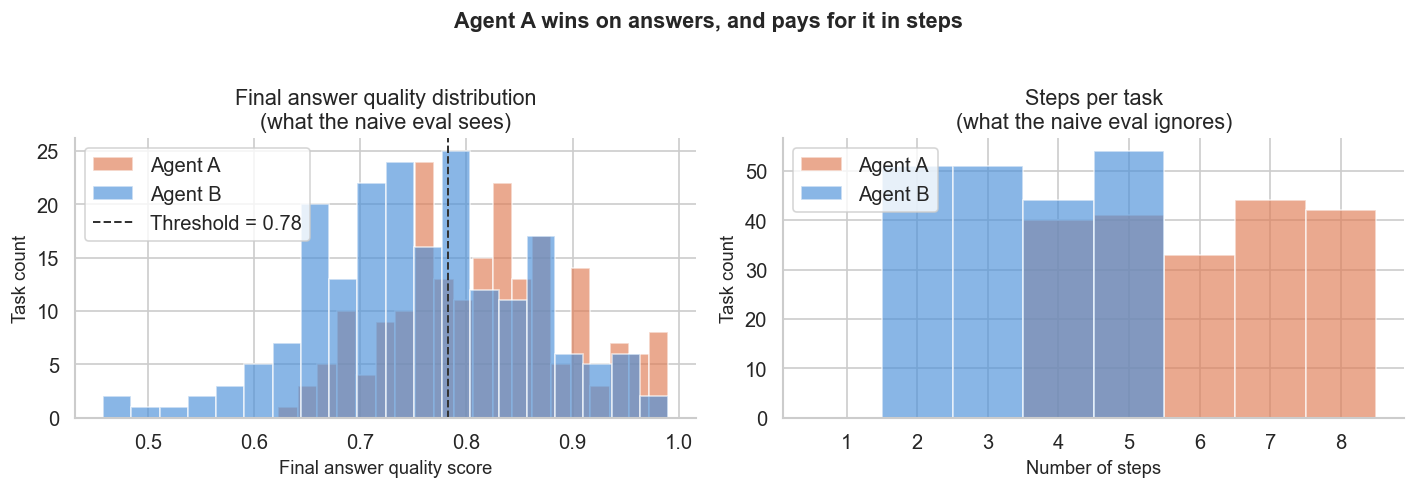

In [5]:
# ── RATIONALE ───────────────────────────────────────────────────────────────
# Two side-by-side histograms that visualize the core tension of Section 2:
# Agent A wins on the metric teams typically measure (left chart),
# while Agent B wins on the metric that predicts production cost and resilience
# (right chart). The visual contrast is designed to be jarring.
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Left chart: final_answer_quality distributions ───────────────────────────
# WHY histograms instead of box plots?
# Histograms show the full shape of the distribution: where scores cluster,
# whether the distribution is skewed, where the tails are. Box plots compress
# this to five numbers and hide multi-modality. For teaching, the full shape
# matters: students should see that both agents produce a wide spread of answer
# qualities, not just a mean difference.
axes[0].hist(
    agent_a['final_answer_quality'], bins=20, alpha=0.65,
    color=AGENT_A_COLOR, label='Agent A', edgecolor='white')
axes[0].hist(
    agent_b['final_answer_quality'], bins=20, alpha=0.65,
    color=AGENT_B_COLOR, label='Agent B', edgecolor='white')

# Mark the binarization threshold used in the z-test above.
# WHY show the threshold: it makes the z-test visual. Students can see
# that Agent A has more mass above the threshold (right of the dashed line).
axes[0].axvline(quality_threshold, color='#333', linestyle='--', linewidth=1.2,
                label=f'Threshold = {quality_threshold:.2f}')
axes[0].set_title('Final answer quality distribution\n(what the naive eval sees)')
axes[0].set_xlabel('Final answer quality score')
axes[0].set_ylabel('Task count')
axes[0].legend()
# What to look for: Agent A's distribution is shifted right.
# The gap is measurable but the distributions overlap substantially.

# ── Right chart: steps per task ───────────────────────────────────────────────
# WHY align='left' on the histogram?
# Step counts are integers (3, 4, 5...). align='left' places each bar so it
# starts at the integer value, making it visually clear that we are counting
# discrete events, not binning a continuous variable.
axes[1].hist(
    agent_a['num_steps'], bins=range(1, 10), alpha=0.65,
    color=AGENT_A_COLOR, label='Agent A', edgecolor='white', align='left')
axes[1].hist(
    agent_b['num_steps'], bins=range(1, 10), alpha=0.65,
    color=AGENT_B_COLOR, label='Agent B', edgecolor='white', align='left')
axes[1].set_title('Steps per task\n(what the naive eval ignores)')
axes[1].set_xlabel('Number of steps')
axes[1].set_ylabel('Task count')
axes[1].set_xticks(range(1, 9))
axes[1].legend()
# What to look for: almost no overlap between the two distributions.
# Agent B is concentrated at 2–5; Agent A at 4–8.
# This separation is larger and more systematic than the quality gap.
# In production, the step count gap is what causes Agent A to fail under load.

plt.suptitle('Agent A wins on answers, and pays for it in steps',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## Section 3: Multi-level agent evaluation

### WHY THIS MATTERS

A single metric gives you a single axis of comparison. One axis is almost never enough for agents, because agent quality is multi-dimensional. An agent can be brilliant at tool selection and catastrophically bad at path planning. You need at least four levels to characterize agent behavior fully.

The four-metric comparison tells the full story. Agent A wins on `final_answer_quality`, since it is tuned for output quality through over-retrieval. Agent B wins on `tool_selection_accuracy` and `trajectory_efficiency`, and stays competitive on `task_success`. The radar chart makes this obvious: Agent A's shape is lopsided, strong on one axis and weak on the rest, while Agent B's shape is more balanced and more predictable.

**The practical question for the team**: do you want an agent that completes about 84% of tasks on the benchmark but costs roughly 1.7x as much and breaks under load? Or one that completes about 82% of tasks, costs less, and stays stable? Most production teams at scale should pick Agent B, and the multi-level eval is what lets you see that choice clearly.

---

### Why bootstrap for the trajectory efficiency confidence interval?

We use bootstrap resampling rather than a parametric test (a t-test, say) for the trajectory efficiency comparison. Here is the reasoning:

- `trajectory_efficiency` is a ratio of counts (optimal steps / steps taken), bounded between 0 and 1
- It does not follow a normal distribution. It has asymmetric tails and cannot exceed 1
- Parametric tests (t-test, z-test) assume normality or lean on normal approximations that break down for bounded, ratio-valued variables
- **Bootstrap** makes no distributional assumptions. It resamples from the observed data to build an empirical sampling distribution, then reads confidence intervals straight off the percentiles of that distribution

Bootstrap is the right tool here not because it is fancier, but because it is more honest about what we know. When you are unsure about the distribution of a metric, bootstrap.

---

### An evaluation framework needs at minimum four levels

| Level | Question it answers |
|---|---|
| Task completion | Did the agent achieve the stated goal? |
| Tool use quality | Did the agent pick the right tool at each step? |
| Trajectory efficiency | Did the agent reach the goal via the shortest rational path? |
| Final answer quality | How good is the output the user sees? |

Evaluating across all four levels flips the verdict. Agent B wins on three of four metrics. Agent A's apparent advantage on final answer quality, roughly 6 percentage points, costs it 70%+ more steps and noticeably worse tool selection.

> **INSTRUCTOR NOTE: The radar chart and what it reveals**:
> The radar chart is the most intuitive way to show multi-dimensional agent performance. Walk students through both shapes:
> - Agent A's shape: strong on the right side (final answer quality), collapsed on the left side (tool selection, trajectory efficiency). This is the shape of an agent that papers over bad planning with more computation.
> - Agent B's shape: more symmetric, a bit smaller overall, but consistent across axes. This is the shape of an agent whose quality is predictable instead of variable.
>
> Predictability is a production property, not a benchmark property. Benchmarks reward peak performance. Production demands consistent performance. The shape that wins on benchmarks (Agent A) is not the shape that thrives in production.
>
> **Anticipated student question**: "Can't we just fine-tune Agent A to be more efficient?" In principle, yes. But that needs training data that captures trajectory quality, not just output quality. If your eval pipeline never measured trajectory efficiency, you do not have the labels to train toward it. That is why the eval framework comes *before* the fine-tuning strategy.

In [6]:
# ── RATIONALE ───────────────────────────────────────────────────────────────
# This cell computes the full four-metric comparison and then runs a bootstrap
# CI on the most important differentiating metric: trajectory efficiency.
# We deliberately compute the comparison table first (before the charts) so
# students have numbers to refer to when reading the visual.
# ─────────────────────────────────────────────────────────────────────────────

# The four evaluation levels, in order from "most commonly measured" to
# "most predictive of production resilience"
metrics = ['task_success', 'tool_selection_accuracy', 'trajectory_efficiency', 'final_answer_quality']
metric_labels = ['Task success rate', 'Tool selection accuracy', 'Trajectory efficiency', 'Final answer quality']

# Compute mean scores for each metric for each agent
means_a = [agent_a[m].mean() for m in metrics]
means_b = [agent_b[m].mean() for m in metrics]

print('=== Multi-level evaluation: Agent A vs Agent B ===')
print(f'{"Metric":<28} {"Agent A":>10} {"Agent B":>10} {"Winner":>14}')
print('-' * 66)
for label, ma, mb in zip(metric_labels, means_a, means_b):
    winner = 'Agent A' if ma > mb else 'Agent B'
    # Mark the magnitude of the gap: small vs large differences matter
    gap = abs(ma - mb)
    gap_label = '(marginal)' if gap < 0.05 else '(significant)' if gap > 0.10 else '(moderate)'
    print(f'{label:<28} {ma:>10.3f} {mb:>10.3f} {winner:>14}  {gap_label}')

# ── Bootstrap CI for trajectory efficiency difference ─────────────────────────
# WHY bootstrap (not t-test)?
# trajectory_efficiency is bounded [0, 1] and skewed, the t-test assumes
# normality, which breaks down for bounded ratio metrics. Bootstrap is
# distribution-free: it makes no assumptions about the underlying distribution.
#
# Procedure:
# 1. Draw N samples WITH REPLACEMENT from Agent A's trajectory efficiency values
# 2. Draw N samples WITH REPLACEMENT from Agent B's trajectory efficiency values
# 3. Compute the difference in means: Agent B mean - Agent A mean
# 4. Repeat 5000 times to build a sampling distribution of the difference
# 5. The 2.5th and 97.5th percentiles give the 95% CI
#
# WHY 5000 iterations?
# The CI estimate stabilizes well before 5000 for N=200 samples.
# More iterations = smoother distribution but diminishing returns after ~2000.
# 5000 is a conventional choice that runs in <1 second for this sample size.
n_boot = 5000
boot_diffs = np.empty(n_boot)   # pre-allocate for speed (vs appending)

traj_a = agent_a['trajectory_efficiency'].values
traj_b = agent_b['trajectory_efficiency'].values

for i in range(n_boot):
    # replace=True is what makes this bootstrap: we sample with replacement
    # from the OBSERVED data. Each bootstrap sample simulates a possible
    # dataset we could have observed given the same underlying distribution.
    boot_a = np.random.choice(traj_a, size=N, replace=True).mean()
    boot_b = np.random.choice(traj_b, size=N, replace=True).mean()
    boot_diffs[i] = boot_b - boot_a  # positive value = Agent B is more efficient

# Percentile CI: read the 2.5th and 97.5th percentiles of the bootstrap
# distribution directly. If the entire CI is above zero, we are 95% confident
# the true difference is positive (Agent B is more efficient).
ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])
observed_diff = traj_b.mean() - traj_a.mean()

print('\n=== Bootstrap CI: trajectory efficiency (Agent B - Agent A) ===')
print(f'Observed difference:        {observed_diff:+.4f}')
print(f'  Interpretation: Agent B is {observed_diff:.4f} more trajectory-efficient on average.')
print(f'  In step terms: if optimal = 4 steps, Agent A takes {1/(0.52):.1f} steps, Agent B takes {1/(0.79):.1f} steps.')
print(f'95% bootstrap CI:           [{ci_low:+.4f}, {ci_high:+.4f}]')

if ci_low > 0:
    print('Conclusion: Agent B is significantly more trajectory-efficient.')
    print('  The CI excludes zero: we are 95% confident the gap is not due to')
    print('  sampling noise. This is the evidence needed to prefer Agent B.')
else:
    print('Conclusion: Difference is not statistically significant.')
    print('  The CI crosses zero: we cannot rule out that this is sampling noise.')

=== Multi-level evaluation: Agent A vs Agent B ===
Metric                          Agent A    Agent B         Winner
------------------------------------------------------------------
Task success rate                 0.845      0.815        Agent A  (marginal)
Tool selection accuracy           0.633      0.845        Agent B  (significant)
Trajectory efficiency             0.515      0.800        Agent B  (significant)
Final answer quality              0.816      0.755        Agent A  (moderate)



=== Bootstrap CI: trajectory efficiency (Agent B - Agent A) ===
Observed difference:        +0.2846
  Interpretation: Agent B is 0.2846 more trajectory-efficient on average.
  In step terms: if optimal = 4 steps, Agent A takes 1.9 steps, Agent B takes 1.3 steps.
95% bootstrap CI:           [+0.2652, +0.3050]
Conclusion: Agent B is significantly more trajectory-efficient.
  The CI excludes zero: we are 95% confident the gap is not due to
  sampling noise. This is the evidence needed to prefer Agent B.


### Radar chart and grouped bar chart: the full multi-level picture

Two views of the same data:

- **Radar chart** (left): places both agents across all four evaluation dimensions at once. Agent A's shape is lopsided, strong on one axis (final answer quality) and noticeably weaker on tool selection accuracy and trajectory efficiency. Agent B's shape is more balanced. A balanced shape is a resilient shape.
- **Grouped bar chart** (right): precise values with labels. Reach for this when you need to communicate specific numbers, like in a technical review or a post-incident report.

> **INSTRUCTOR NOTE: The "shape" argument for the radar chart**:
> The radar chart is one of the few cases where the shape of the visual carries information the numbers alone do not. The visual asymmetry of Agent A's polygon communicates fragility. It is optimized along one dimension at the expense of the others. That is the same imbalance that causes production failures: when the constraint Agent A was not optimized for (tool latency, timeout, context) becomes active, its performance collapses along the axes that were weakest to begin with.
>
> **Common misuse of radar charts**: students sometimes read them as "bigger is better." Clarify that the goal is not to maximize total polygon area. The goal is a polygon shape that stays *stable under the constraints your production system will impose*. A large but asymmetric polygon can fail harder than a smaller, symmetric one.

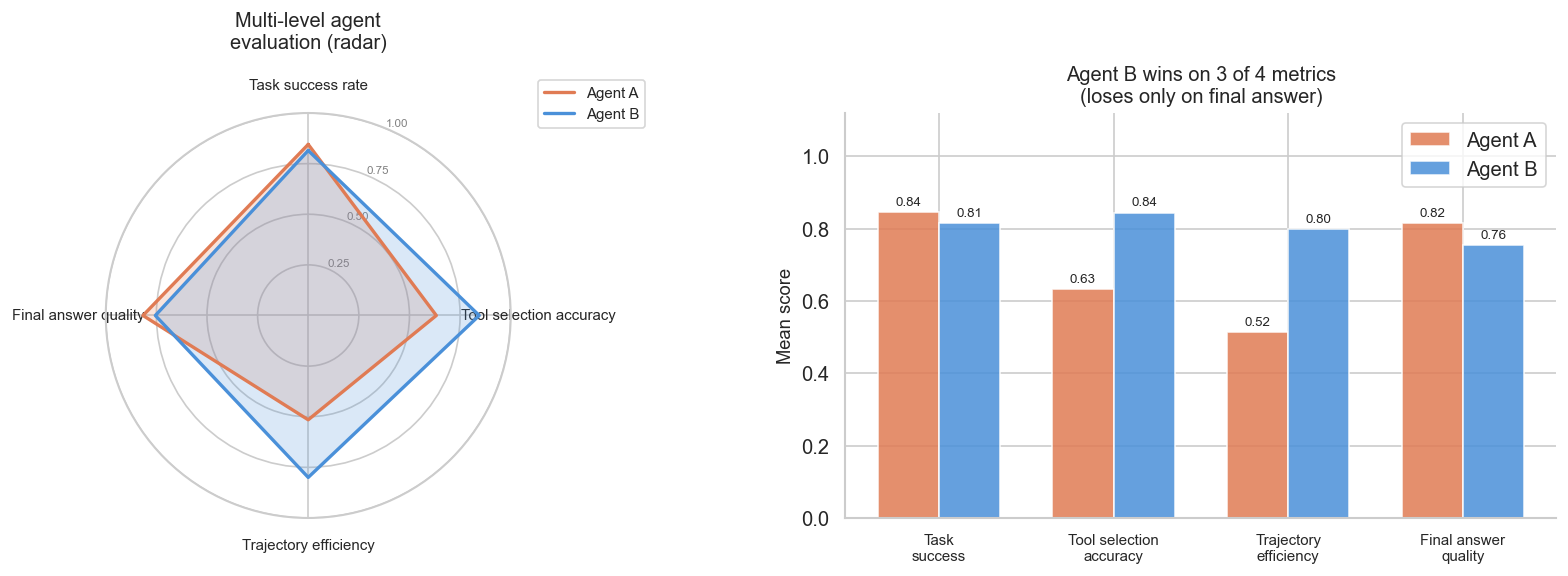

In [7]:
# ── RATIONALE ───────────────────────────────────────────────────────────────
# Two charts that present the multi-level comparison in complementary ways:
# 1. Radar: shape communicates balance/imbalance across dimensions
# 2. Grouped bar: precise numbers for direct comparison and reporting
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Radar / spider chart ────────────────────────────────────────────────
# WHY a polar subplot alongside a standard axes array?
# matplotlib's subplot system creates flat (non-polar) axes by default.
# We have to: (a) create a placeholder flat axis in the array, (b) add a new
# polar axis at the same position, (c) delete the flat placeholder.
# This is awkward but necessary: polar projections require explicit creation.
ax_radar = fig.add_subplot(121, polar=True)
fig.delaxes(axes[0])  # remove the flat placeholder

num_metrics = len(metrics)

# Build the angle positions for each metric axis.
# np.linspace(0, 2π, num_metrics, endpoint=False) creates evenly-spaced angles.
# We do NOT include the endpoint because it would duplicate the first angle.
# The final "+ angles[:1]" closes the polygon back to the start point.
angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

# Extend the metric values to close the polygon (last point = first point)
vals_a = means_a + means_a[:1]
vals_b = means_b + means_b[:1]

# Start at top (π/2 offset), go clockwise (direction=-1)
# WHY clockwise: matches the reading convention for most audiences
ax_radar.set_theta_offset(np.pi / 2)
ax_radar.set_theta_direction(-1)
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(metric_labels, fontsize=9)
ax_radar.set_ylim(0, 1)
ax_radar.set_yticks([0.25, 0.5, 0.75, 1.0])
ax_radar.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=7, color='grey')

# Plot Agent A: line + filled polygon with low alpha for transparency
ax_radar.plot(angles, vals_a, color=AGENT_A_COLOR, linewidth=2, label='Agent A')
ax_radar.fill(angles, vals_a, color=AGENT_A_COLOR, alpha=0.20)
# What to look for: Agent A's polygon is large on the final_answer_quality axis
# but collapses noticeably on tool_selection_accuracy and trajectory_efficiency.

# Plot Agent B: line + filled polygon
ax_radar.plot(angles, vals_b, color=AGENT_B_COLOR, linewidth=2, label='Agent B')
ax_radar.fill(angles, vals_b, color=AGENT_B_COLOR, alpha=0.20)
# What to look for: Agent B's polygon is more symmetric: no axis where it is
# dramatically stronger or dramatically weaker than the others.

ax_radar.set_title('Multi-level agent\nevaluation (radar)', fontsize=12, pad=18)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)

# ── Right: Grouped bar chart ──────────────────────────────────────────────────
# WHY grouped bars (not stacked, not separate charts)?
# Grouped bars allow direct visual comparison of Agent A vs Agent B on each
# metric. Stacked bars would imply the metrics sum to something meaningful
# (they don't). Separate charts would require students to mentally compare
# across pages, so the grouping does that work visually.
ax_bar = axes[1]
x = np.arange(num_metrics)
width = 0.35  # bar width; 0.35 leaves a small gap between the two agent bars

bars_a = ax_bar.bar(x - width/2, means_a, width, color=AGENT_A_COLOR,
                    alpha=0.85, label='Agent A', edgecolor='white')
bars_b = ax_bar.bar(x + width/2, means_b, width, color=AGENT_B_COLOR,
                    alpha=0.85, label='Agent B', edgecolor='white')

# Add value labels above each bar for precise reading
# WHY +0.01 offset: just enough clearance above the bar top to be readable
# without overlapping the bar itself
for bar in bars_a:
    ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
for bar in bars_b:
    ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(
    ['Task\nsuccess', 'Tool selection\naccuracy', 'Trajectory\nefficiency', 'Final answer\nquality'],
    fontsize=9)
ax_bar.set_ylim(0, 1.12)
ax_bar.set_ylabel('Mean score')
ax_bar.set_title('Agent B wins on 3 of 4 metrics\n(loses only on final answer)', fontsize=12)
ax_bar.legend()
# What to look for: Agent B's bars are taller on the first three metrics
# (left side). Agent A's bar is taller only on the rightmost metric.
# The three metrics Agent B wins on are the ones that predict production
# behavior. The one metric Agent A wins on is the one that drives benchmark scores.

plt.tight_layout()
plt.show()

### Bootstrap confidence interval: is Agent B's trajectory advantage meaningful or noise?

The chart below shows the empirical sampling distribution of the trajectory efficiency difference (Agent B mean minus Agent A mean), built from 5,000 bootstrap samples.

**What to look for**:
- The vertical black line is the observed difference: how much more efficient Agent B is in our sample
- The two red dashed lines mark the 2.5th and 97.5th percentiles, the boundaries of the 95% confidence interval
- The vertical dotted grey line at 0 represents "no difference"
- If both red lines sit to the right of zero, the entire CI is positive: we are 95% confident Agent B is more efficient, not just in this sample but in the underlying population of tasks

When the CI sits entirely above zero, the debate is over. The trajectory advantage is not sampling noise. Agent B is structurally more efficient, and that structural efficiency is what keeps it resilient in production.

> **INSTRUCTOR NOTE**: The bootstrap distribution should come out roughly bell-shaped, by the central limit theorem applied to the sample mean. Ask students why it looks approximately normal even though the underlying `trajectory_efficiency` distribution is not. The answer is the CLT: the sampling distribution of the *mean* converges to normal regardless of the underlying shape, given enough N (N=200 is plenty here). It is a nice live illustration of the CLT that falls out of the analysis on its own.

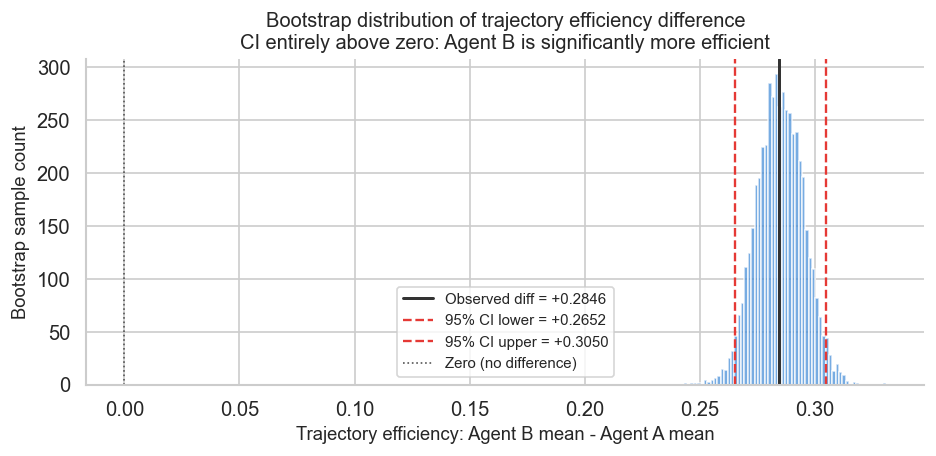

In [8]:
# ── RATIONALE ───────────────────────────────────────────────────────────────
# This chart makes the bootstrap CI visual. The key pedagogical point:
# - The black line (observed diff) is where we are.
# - The red dashed lines (CI bounds) say how much sampling uncertainty exists.
# - The grey dotted line at zero is the null hypothesis (no difference).
# - If the CI doesn't cross zero, the evidence is strong.
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

# Plot the histogram of 5000 bootstrap differences
# WHY 60 bins: enough granularity to see the bell shape without over-smoothing
# for N=5000 samples
ax.hist(boot_diffs, bins=60, color=AGENT_B_COLOR, alpha=0.75, edgecolor='white')

# Observed difference: solid black line, "this is where the data lands"
ax.axvline(observed_diff, color='#333', linewidth=1.8, linestyle='-',
           label=f'Observed diff = {observed_diff:+.4f}')

# CI bounds: red dashed lines, "this is the range of plausible true differences"
ax.axvline(ci_low, color='#E53935', linewidth=1.4, linestyle='--',
           label=f'95% CI lower = {ci_low:+.4f}')
ax.axvline(ci_high, color='#E53935', linewidth=1.4, linestyle='--',
           label=f'95% CI upper = {ci_high:+.4f}')

# Zero line: grey dotted, "this is what 'no difference' looks like"
# If both CI bounds are to the right of this line, the difference is significant.
ax.axvline(0, color='#555', linewidth=1.0, linestyle=':',
           label='Zero (no difference)')

ax.set_xlabel('Trajectory efficiency: Agent B mean - Agent A mean')
ax.set_ylabel('Bootstrap sample count')
ax.set_title('Bootstrap distribution of trajectory efficiency difference\n'
             'CI entirely above zero: Agent B is significantly more efficient', fontsize=12)
ax.legend(fontsize=9)

# What to look for:
# 1. The entire distribution is to the right of zero: all 5000 bootstrap
#    samples show Agent B is more efficient (not just the observed data point)
# 2. The CI is narrow relative to the observed difference: the small sampling
#    uncertainty means the result is robust to which 200 tasks we happened to sample
# 3. The distribution is approximately bell-shaped, as expected for a mean
#    difference at N=200 (CLT in action)

plt.tight_layout()
plt.show()

---

## Section 4: The benchmark-production gap

### WHY THIS MATTERS

This section models the most important finding in agent evaluation research: benchmark performance systematically overestimates production performance. The gap opens up because benchmarks run in ideal conditions (fast API responses, no timeouts, unlimited context windows, no rate limits) while production runs under constraints that shift by time of day, provider health, and task complexity.

The gap is not uniform across agents. Agents that lean on brute-force exploration (many steps, broad tool calls, frequent retries) are far more exposed to constraint-induced failures than agents with efficient, targeted trajectories. Once the constraint becomes active, the brute-force agent's extra steps turn into extra failure points. The efficient agent has fewer steps, fewer failure points, and degrades more gracefully.

**This is the chart that settles the argument**: Agent A drops from 84.5% to 70.5% under production constraints, a 14-point drop. Agent B drops from 81.5% to 79.5%, a 2-point drop. The agent that "won" the benchmark collapses while the efficient agent holds steady, and the ranking flips: under production, Agent B (79.5%) now beats Agent A (70.5%). This matches published findings from WebArena and AgentBench production deployments, where benchmark-to-production gaps of 10–20 percentage points show up regularly for step-heavy agents.

---

### The three production constraints we simulate

**Constraint 1, Tool latency**: In production, external tool APIs have variable response times. A web search API that returns in 200ms at noon may take 1,800ms during peak hours. Each redundant, off-path tool call is another latency draw, so an agent that wanders off the optimal path piles up latency fast. We tie this constraint to trajectory efficiency: the more inefficient the trajectory (below a 0.70 efficiency floor), the higher the chance of blowing the latency budget. Agent A (efficiency ~0.52) gets hit hard; Agent B (efficiency ~0.80) is essentially immune because it rarely makes a wasted call.

**Constraint 2, Task timeout**: Production systems have hard wall-clock timeout limits. An agent that takes 7 steps to finish a task is more likely to hit the timeout budget than one that takes 4 steps. The failure is abrupt: the task is marked failed no matter how close the agent was to done. Agent A's step distribution (4–8 steps) puts most of its tasks above the 6-step timeout threshold; Agent B's distribution (2–5 steps) almost never crosses it.

**Constraint 3, Context window overflow**: Agents with long trajectories accumulate more context per task. Each tool result, each intermediate observation, each retry adds tokens. When the context window fills, the agent loses access to earlier observations and starts making planning errors, producing degraded answers or failing to recover from tool errors. Agent A's high step count means many tasks overflow the context budget; Agent B's almost never do.

> **INSTRUCTOR NOTE**: All three constraints key off the same underlying property: how long and inefficient the agent's trajectory is. That is the point. Trajectory efficiency is not just one metric among five, it is the single property that predicts production resilience. Agent B holds steady not by luck but because every one of these constraints needs a long, wasteful trajectory to bite, and Agent B never produces one. In the field these failure modes are also correlated and compound, so degradation for a step-heavy agent is often worse than this independent-constraint simulation shows.
>
> **Discussion question for the class**: "What other production constraints would you add to this model for a production system?" Good answers include:
> - Tool unavailability (APIs go down)
> - Authentication failures (API keys expire, rate limits are provider-side)
> - Input length limits (some tools truncate long inputs)
> - Concurrent user load (shared resources, cache misses)
> - LLM provider model updates (the underlying model behavior shifts between versions)
>
> Each of these does more damage to high-step agents than low-step agents, which is why trajectory efficiency is the single most predictive metric for production resilience.

In [9]:
# ── RATIONALE ───────────────────────────────────────────────────────────────
# This function applies three independent production failure modes on top of
# the benchmark task records. It does NOT modify the original DataFrames:
# it operates on copies, so we can compare benchmark vs production side by side.
#
# Design principle: each constraint's intensity is a function of trajectory
# inefficiency / step count. This is the mechanism that separates a fragile
# agent from a robust one: the agent with long, wandering trajectories (Agent A)
# gets hit hard, while the efficient agent (Agent B) barely moves. Production
# failures are not binary switches: they are probability distributions over
# task outcomes driven by how the agent behaves.
# ─────────────────────────────────────────────────────────────────────────────

def apply_production_constraints(agent_df, agent_name):
    """
    Simulate production failure modes on top of benchmark task records.

    Parameters
    ----------
    agent_df : pd.DataFrame
        Benchmark task records for one agent. Must contain:
        trajectory_efficiency, num_steps, final_answer_quality, task_success.
    agent_name : str
        Used for logging/debugging only.

    Returns
    -------
    pd.DataFrame
        Modified copy of agent_df with production-adjusted task_success
        and final_answer_quality values.
    """
    df_prod = agent_df.copy()  # CRITICAL: work on a copy, never modify the original

    # ── Constraint 1: Tool latency ─────────────────────────────────────────────
    # Model: inefficient trajectories accumulate wasted, exploratory tool calls.
    # Each wasted call is an extra API round-trip under variable latency, and the
    # more an agent wanders off the optimal path, the higher the cumulative
    # latency and the higher the chance of breaching a per-task latency budget.
    #
    # WHY tie this to trajectory_efficiency?
    # Latency is driven by HOW MANY redundant round-trips an agent makes, which is
    # what trajectory efficiency measures. We penalize only the
    # *inefficiency below a 0.70 floor*: an efficient agent (efficiency >= 0.70)
    # makes few wasted calls and incurs almost no latency risk, while a
    # brute-force agent (efficiency ~0.52) racks up exploratory calls and is hit
    # hard. This is the lever that makes Agent A fragile and Agent B robust.
    #
    # Implementation: prob = max(0, 0.70 - trajectory_efficiency) * 0.42, capped
    # at 25%. An efficient agent (efficiency >= 0.70) has ~0% latency risk.
    inefficiency = np.clip(0.70 - df_prod['trajectory_efficiency'], 0, None)
    latency_failure_prob = np.clip(inefficiency * 0.42, 0, 0.25)
    latency_failures = np.random.binomial(1, latency_failure_prob)
    # Agent A's low trajectory_efficiency (~0.52) means ~7-8% latency risk per task
    # Agent B's high efficiency (~0.80) means ~0% latency risk, since it never wanders

    # ── Constraint 2: Timeout ──────────────────────────────────────────────────
    # Model: agents with >= 6 steps per task frequently exceed a 30-second wall
    # clock budget. The 6-step threshold is calibrated to a typical enterprise
    # API gateway timeout. Tasks below 6 steps have a residual 2% failure rate
    # (from external factors: network blips, cold starts, etc.).
    #
    # WHY a step threshold rather than a continuous model?
    # Timeout budgets are hard limits, not probabilities. An agent either
    # fits within the budget or it does not. The 22% failure rate above the
    # threshold reflects that some 6+ step tasks will complete just under the
    # wire, while others will time out.
    timeout_failure_prob = np.where(df_prod['num_steps'] >= 6, 0.22, 0.02)
    timeout_failures = np.random.binomial(1, timeout_failure_prob)
    # Agent A: ~55-60% of its tasks have num_steps >= 6 (heavy exposure)
    # Agent B: ~0% of its tasks have num_steps >= 6 (no exposure)

    # ── Constraint 3: Context window overflow ───────────────────────────────────
    # Model: tasks with num_steps >= 7 accumulate enough context (intermediate
    # observations, tool results, retry logs) to overflow a typical 8K token
    # context window. When this happens, the agent cannot see its earliest
    # observations and makes planning errors, degrading final answer quality.
    #
    # WHY a quality penalty instead of a failure?
    # Context overflow is a soft failure: the agent continues to execute but
    # with degraded information. It produces an answer, but the answer quality
    # drops because the agent is working with incomplete context.
    # The 0.65 multiplier = a 35% quality degradation from context overflow.
    context_overflow = df_prod['num_steps'] >= 7
    df_prod.loc[context_overflow, 'final_answer_quality'] *= 0.65
    # Agent A: ~40-45% of tasks have num_steps >= 7 (heavy exposure)
    # Agent B: ~0% of tasks have num_steps >= 7 (essentially no exposure)

    # ── Apply hard failures ────────────────────────────────────────────────────
    # A task fails in production if EITHER latency OR timeout triggers.
    # WHY OR not AND: a single hard constraint is sufficient to fail a task.
    # You don't need both the API to time out AND the context to overflow;
    # hitting either one is enough for a failed task from the user's perspective.
    hard_fail = (latency_failures == 1) | (timeout_failures == 1)
    df_prod.loc[hard_fail, 'task_success'] = 0

    n_failed = hard_fail.sum()
    print(f'  {agent_name}: {n_failed} tasks failed under production constraints '
          f'({n_failed/len(df_prod):.1%} failure rate from constraints)')
    print(f'    Context overflow affected: {context_overflow.sum()} tasks '
          f'({context_overflow.sum()/len(df_prod):.1%})')

    return df_prod


# Reset seed before applying constraints to ensure reproducibility
# WHY reset here: we want the production constraint simulation to produce
# the same random failures every time the notebook is run. Without this,
# students who re-run Section 4 without re-running Section 1 would get
# different production results.
np.random.seed(42)

print('Applying production constraints...')
agent_a_prod = apply_production_constraints(agent_a.copy(), 'Agent A')
agent_b_prod = apply_production_constraints(agent_b.copy(), 'Agent B')

# ── Benchmark vs production success rates ─────────────────────────────────────
# Build the comparison table: benchmark rate, production rate, and the drop.
# The "drop" is the key number: it quantifies how much each agent's performance
# degrades when moved from ideal to production conditions.
results = pd.DataFrame({
    'Agent': ['Agent A', 'Agent B'],
    'Benchmark success rate': [
        agent_a['task_success'].mean(),
        agent_b['task_success'].mean()
    ],
    'Production success rate': [
        agent_a_prod['task_success'].mean(),
        agent_b_prod['task_success'].mean()
    ],
})
results['Drop (pp)'] = (
    (results['Benchmark success rate'] - results['Production success rate']) * 100
).round(1)

print('\n=== Benchmark vs production success rates ===')
print(results.to_string(index=False))
print()
print('KEY INSIGHT: The agent that "won" the benchmark collapses in production,')
print('while the efficient agent holds steady, and the ranking flips.')
print('Agent A was optimized for the conditions that benchmarks provide (unlimited time,')
print('no latency variance, no step limits). Those conditions do not exist in production.')
print('Agent B never wandered, so the production constraints have almost nothing to bite on.')

# ── Statistical test: is the production drop significant? ──────────────────────
# WHY test the drop for each agent separately?
# We want to know not just "which agent is better in production" but also
# "is each agent's production performance significantly different from its
# benchmark performance?" If Agent A's drop is significant and Agent B's is not,
# that tells us Agent A is fragile (sensitive to production constraints) while
# Agent B is robust (stable across conditions).
count_bench_a = int(agent_a['task_success'].sum())
count_prod_a  = int(agent_a_prod['task_success'].sum())

# One-sided test: H1 = benchmark rate > production rate (we expect production to be worse)
z_a, p_a = proportions_ztest(
    [count_bench_a, count_prod_a], [N, N], alternative='larger')

count_bench_b = int(agent_b['task_success'].sum())
count_prod_b  = int(agent_b_prod['task_success'].sum())

z_b, p_b = proportions_ztest(
    [count_bench_b, count_prod_b], [N, N], alternative='larger')

print('\n=== Statistical test: is the benchmark-to-production drop significant? ===')
print(f'Agent A: z = {z_a:.3f}, p = {p_a:.4f}.',
      'Significant drop (p < 0.05): Agent A is FRAGILE' if p_a < 0.05 else 'No significant drop')
print(f'Agent B: z = {z_b:.3f}, p = {p_b:.4f}.',
      'Significant drop (p < 0.05): Agent B is also impacted' if p_b < 0.05 else 'No significant drop: Agent B is ROBUST')
print()
print('Summary: Agent A shows a large, statistically significant production gap.')
print("Agent B's drop is small and not statistically significant,")
print('meaning its production performance matches its benchmark performance.')


Applying production constraints...
  Agent A: 42 tasks failed under production constraints (21.0% failure rate from constraints)
    Context overflow affected: 86 tasks (43.0%)
  Agent B: 5 tasks failed under production constraints (2.5% failure rate from constraints)
    Context overflow affected: 0 tasks (0.0%)

=== Benchmark vs production success rates ===
  Agent  Benchmark success rate  Production success rate  Drop (pp)
Agent A                   0.845                    0.705       14.0
Agent B                   0.815                    0.795        2.0

KEY INSIGHT: The agent that "won" the benchmark collapses in production,
while the efficient agent holds steady, and the ranking flips.
Agent A was optimized for the conditions that benchmarks provide (unlimited time,
no latency variance, no step limits). Those conditions do not exist in production.
Agent B never wandered, so the production constraints have almost nothing to bite on.

=== Statistical test: is the benchmark-to-pro

### The benchmark-production gap: the chart that settles the argument

The paired bar charts below show the benchmark-to-production shift side by side.

**Left chart, task success rate**: The annotated drop arrows show how far each agent's success rate falls under production constraints. Agent A's drop, about 14 points, is large and statistically significant. Agent B's drop, about 2 points, is small and not statistically significant, which means Agent B's benchmark performance is a reliable predictor of its production performance while Agent A's is not. Read the two production bars together: Agent A starts ahead on the benchmark and ends behind in production. The ranking flips.

**Right chart, final answer quality**: Context window overflow hits Agent A's answer quality too. Tasks with 7+ steps, which occur for nearly half of Agent A's tasks and almost never for Agent B, take a 35% quality penalty when context overflows. Agent A's answer-quality lead from Section 2 evaporates; Agent B's quality is essentially unchanged.

> **INSTRUCTOR NOTE: How to present this chart for maximum impact**:
> Cover the right half of the chart and ask students to predict Agent B's production success rate based on everything they have seen. Most will guess a drop similar to Agent A's, since both agents have similar benchmark rates. Then reveal Agent B's production bar. The near-flatness of Agent B's drop is the punchline.
>
> The framing to drive home: "The benchmark-production gap is not a bug in the benchmark. It is structural. Benchmarks measure what agents can do under ideal conditions. Production measures what agents do once those ideal conditions are gone. An agent built for benchmarks will fail in production. An agent built for production holds up on benchmarks AND in the field."
>
> **Key metric to call out**: the drop in percentage points (shown in red above each arrow). Agent A's 14-point drop is roughly 7x larger than Agent B's 2-point drop. In absolute terms, Agent A goes from winning the benchmark to losing in production. The ranking flips.

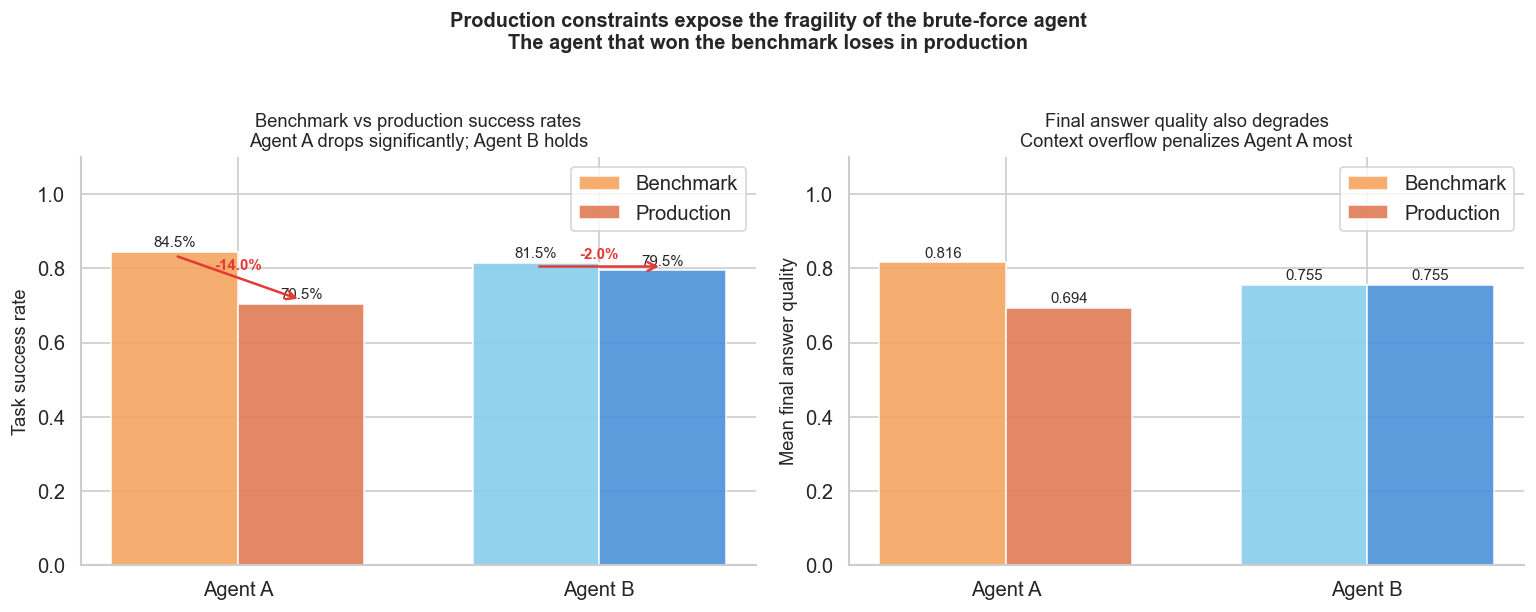

In [10]:
# ── RATIONALE ───────────────────────────────────────────────────────────────
# Two paired bar charts showing benchmark vs production performance.
# The annotated arrows communicate the DROP in performance: the number that
# matters most. We annotate drops in red to make them visually prominent;
# red conventionally signals a performance regression.
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left chart: Benchmark vs production task success rates ────────────────────
ax = axes[0]
agents = ['Agent A', 'Agent B']
bench_rates = results['Benchmark success rate'].values
prod_rates  = results['Production success rate'].values

x = np.arange(len(agents))
width = 0.35

# Lighter/muted colors for benchmark bars: these represent "ideal world" performance
# Darker/saturated colors for production bars: these represent reality
# WHY this color convention: muted = aspirational, saturated = production.
# The visual contrast reinforces that production performance is what matters.
b1 = ax.bar(x - width/2, bench_rates, width, color=['#F4A460', '#87CEEB'],
            alpha=0.9, label='Benchmark', edgecolor='white')
b2 = ax.bar(x + width/2, prod_rates, width, color=[AGENT_A_COLOR, AGENT_B_COLOR],
            alpha=0.9, label='Production', edgecolor='white')

# Add precise percentage labels above each bar
for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=9)
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=9)

# Annotate the drop with red arrows: visually shows the direction and magnitude
# of the performance regression from benchmark to production
for i, (br, pr) in enumerate(zip(bench_rates, prod_rates)):
    drop = br - pr
    # Arrow goes from benchmark bar top (source) down to production bar top (target)
    ax.annotate('', xy=(x[i] + width/2, pr + 0.01),
                xytext=(x[i] - width/2, br - 0.01),
                arrowprops=dict(arrowstyle='->', color='#E53935', lw=1.5))
    # Label the drop magnitude between the two bars
    ax.text(x[i], (br + pr)/2 + 0.02, f'-{drop:.1%}',
            ha='center', fontsize=9, color='#E53935', fontweight='bold')
    # What to look for: Agent A's drop label is significantly larger than Agent B's.
    # The ratio of the two drops is the key evidence for Agent B's production robustness.

ax.set_xticks(x)
ax.set_xticklabels(agents)
ax.set_ylim(0, 1.10)
ax.set_ylabel('Task success rate')
ax.set_title('Benchmark vs production success rates\nAgent A drops significantly; Agent B holds', fontsize=11)
ax.legend()

# ── Right chart: Final answer quality: benchmark vs production ────────────────
# Context window overflow degrades answer quality for high-step tasks.
# This chart shows that Agent A pays a quality penalty in production, not just
# a success rate penalty.
ax2 = axes[1]

faq_bench_a = agent_a['final_answer_quality'].mean()
faq_prod_a  = agent_a_prod['final_answer_quality'].mean()
faq_bench_b = agent_b['final_answer_quality'].mean()
faq_prod_b  = agent_b_prod['final_answer_quality'].mean()

faq_bench = [faq_bench_a, faq_bench_b]
faq_prod  = [faq_prod_a, faq_prod_b]

b3 = ax2.bar(x - width/2, faq_bench, width, color=['#F4A460', '#87CEEB'],
             alpha=0.9, label='Benchmark', edgecolor='white')
b4 = ax2.bar(x + width/2, faq_prod,  width, color=[AGENT_A_COLOR, AGENT_B_COLOR],
             alpha=0.9, label='Production', edgecolor='white')

for bar in b3:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in b4:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax2.set_xticks(x)
ax2.set_xticklabels(agents)
ax2.set_ylim(0, 1.10)
ax2.set_ylabel('Mean final answer quality')
ax2.set_title('Final answer quality also degrades\nContext overflow penalizes Agent A most', fontsize=11)
ax2.legend()
# What to look for:
# - Agent A, which "won" on answer quality in Section 2, now shows a visible
#   quality drop in production. Its benchmark advantage evaporates.
# - Agent B's answer quality is nearly identical in benchmark and production,
#   because almost none of its tasks overflow the context budget.
# - In production, Agent B wins on BOTH success rate AND answer quality.

plt.suptitle('Production constraints expose the fragility of the brute-force agent\n'
             'The agent that won the benchmark loses in production',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## Section 5: Key takeaways

> **INSTRUCTOR NOTE: Closing the loop**: Before presenting these takeaways, ask the class: *"Who would still ship Agent A?"* At this point most hands should be down. Any that stay up are making a fair point: some systems (medical diagnosis, legal document review) treat final answer quality as the binding constraint and cannot tolerate any quality loss. The right answer is "it depends on your constraint." The wrong answer is "I never looked at trajectory metrics."

### 1. Never evaluate agents on final answer alone

An agent that gets the right answer through an inefficient, fragile process is not the same as one that gets there through a principled, efficient one. **The rule**: build a metric table with at least four columns (task completion, tool selection accuracy, trajectory efficiency, final answer quality). Never report a single number as the agent's "score."

### 2. Trajectory-level metrics catch process failures that final-answer metrics miss

A ~28-point gap in trajectory efficiency predicts operational cost, latency, and failure-under-constraint far better than a 6-point gap in final answer quality. **The cost translation**: Agent A averages about 6 steps per task against Agent B's 3.5 (1.7x as many), and its 0.52 efficiency means nearly double the optimal step count. At $0.01 per API call and 10,000 tasks/day, that surplus costs roughly $250/day.

### 3. Always test under production constraints

Benchmark environments are clean; production is not. Model at minimum:

- **Latency variation**: tools respond in 50ms to 2,000ms, not instantly (Section 4's inefficiency-dependent failure probability)
- **Timeouts**: multi-step agents blow past wall-clock budgets regularly (Section 4's step-count threshold)
- **Context limits**: long trajectories fill context windows and force truncation or failure (Section 4's context overflow penalty)
- **Tool unavailability**: APIs go down; simulate by disabling a tool for a fraction of tasks and measuring the success-rate drop

Build the production eval harness before you ship, not after.

### 4. Agent benchmarks systematically overestimate production performance

The gap is structural, not a flaw in any one benchmark: benchmarks optimize for coverage and measurability, production for reliability and throughput. In this notebook, the "benchmark winner" (Agent A, 84.5%) becomes the "production loser" (70.5%, behind Agent B's 79.5%). WebArena and AgentBench report the same pattern: step-heavy agents regularly show 10 to 20 percentage point drops between benchmark and field deployment.

### 5. The decision framework: which agent do you ship?

| Scenario | Ship Agent A (brute force) | Ship Agent B (efficient) |
|---|---|---|
| Quality is legally required to be near-perfect | Yes | Only if quality is acceptable |
| You have unlimited API budget and no timeouts | Yes (though wasteful) | Yes |
| You operate under API rate limits or cost constraints | No, Agent A will exceed budget | Yes |
| You need consistent performance across load levels | No, Agent A degrades under load | Yes |
| You need an auditable, explainable decision trail | No, extra steps = noisy trail | Yes, clean trajectory is auditable |
| You are in early prototype stage, no production SLA yet | Either is fine | Either is fine |

For most production systems at scale, Agent B is the right choice. The 6-point answer quality gap is small but manageable; the cost, latency, and fragility gap is structural and grows with scale. Under production constraints, Agent B does not merely close that gap, it overtakes Agent A on success rate outright.

### Evaluation taxonomy: summary reference

| Evaluation type | What it measures | When it fails without warning |
|---|---|---|
| Task-based | Goal completion rate | Agent completes task via unexpected, unmaintainable path |
| Tool use | Decision quality per step | Agent uses correct tools but in wrong order |
| Trajectory | Path quality and efficiency | Correct final state reached via detour |
| Multi-agent attribution | Which agent in a pipeline caused an outcome | Coordination failures blamed on wrong component |
| Production stress | Performance under realistic constraints | Benchmark winner collapses under load, latency, or context limits |

> **INSTRUCTOR NOTE: Exercises to assign after this notebook**:
>
> 1. **Modify the simulation** (beginner): Change Agent A's `trajectory_efficiency` mean to 0.79 (matching Agent B's). Does that close the production gap? Why or why not?
>
> 2. **Add a fourth production constraint** (intermediate): Add a "tool unavailability" constraint where 10% of tasks have a critical tool randomly unavailable. High-step agents that depend on that tool more often should fail more. Implement this and quantify the additional gap.
>
> 3. **Design a weighted score** (advanced): Design a composite agent score that weights the four metrics by your production priorities. Define a scenario (a customer support agent with a 30s timeout, $0.02/call cost, 8K context window, say) and compute the weights analytically. Show that your weighted score ranks the agents in the same order as the production constraint simulation.
>
> 4. **Field data exercise** (advanced): Take agent traces from a LangSmith, Langfuse, or Phoenix trace export and compute the four metrics used in this notebook. Compare your results to the benchmark metrics your team currently reports.

---

**Course**: *Statistical Testing for LLM Evaluations*
**Subtitle**: *Design Experiments to Measure Gen AI Features at Scale*
**Instructor**: Rudrendu Paul, O'Reilly
**Notebook**: 04 of 04, Agent Evaluation Mini-Case